# Configuración básica

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [127]:
x = Variable()

# Implementación de métodos

In [128]:
# Implementar para hallar raíces de las derivadas, no de f

def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    
    df = f.derivative()

    fa = df.eval(a)
    fb = df.eval(b)

    if fa * fb > 0:
        raise ValueError(
            "La derivada no cambia de signo en el intervalo"
        )
    
    history = []

    for step in range(max_iter):

        xn = (a + b) / 2

        history.append(xn)

        fxn = df.eval(xn)

        if abs(fxn) < tol:
            return xn, step + 1, history

        if fa * fxn < 0:
            b = xn
            fb = fxn
        else:
            a = xn
            fa = fxn

    return xn, max_iter, history

def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    
    df = f.derivative()
    ddf = df.derivative()

    xn = x0
    
    history = [xn]

    for step in range(max_iter):

        g = df.eval(xn)
        dg = ddf.eval(xn)

        if abs(g) < tol:
            return xn, step, history

        if abs(dg) < 1e-12:
            raise ValueError(
                "Segunda derivada cercana a cero"
            )

        xn_new = xn - g / dg
        
        history.append(xn_new)

        if abs(xn_new - xn) < tol:
            return xn_new, step + 1, history

        xn = xn_new

    return xn, max_iter, history

def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    
    df = f.derivative()

    xn = x0
    
    history = [xn]

    for step in range(max_iter):

        grad = df.eval(xn)

        if abs(grad) < tol:
            return xn, step, history

        xn_new = xn - lr * grad
        
        history.append(xn_new)

        if abs(xn_new - xn) < tol:
            return xn_new, step + 1, history

        xn = xn_new

    return xn, max_iter, history
    

### Prueba de métodos

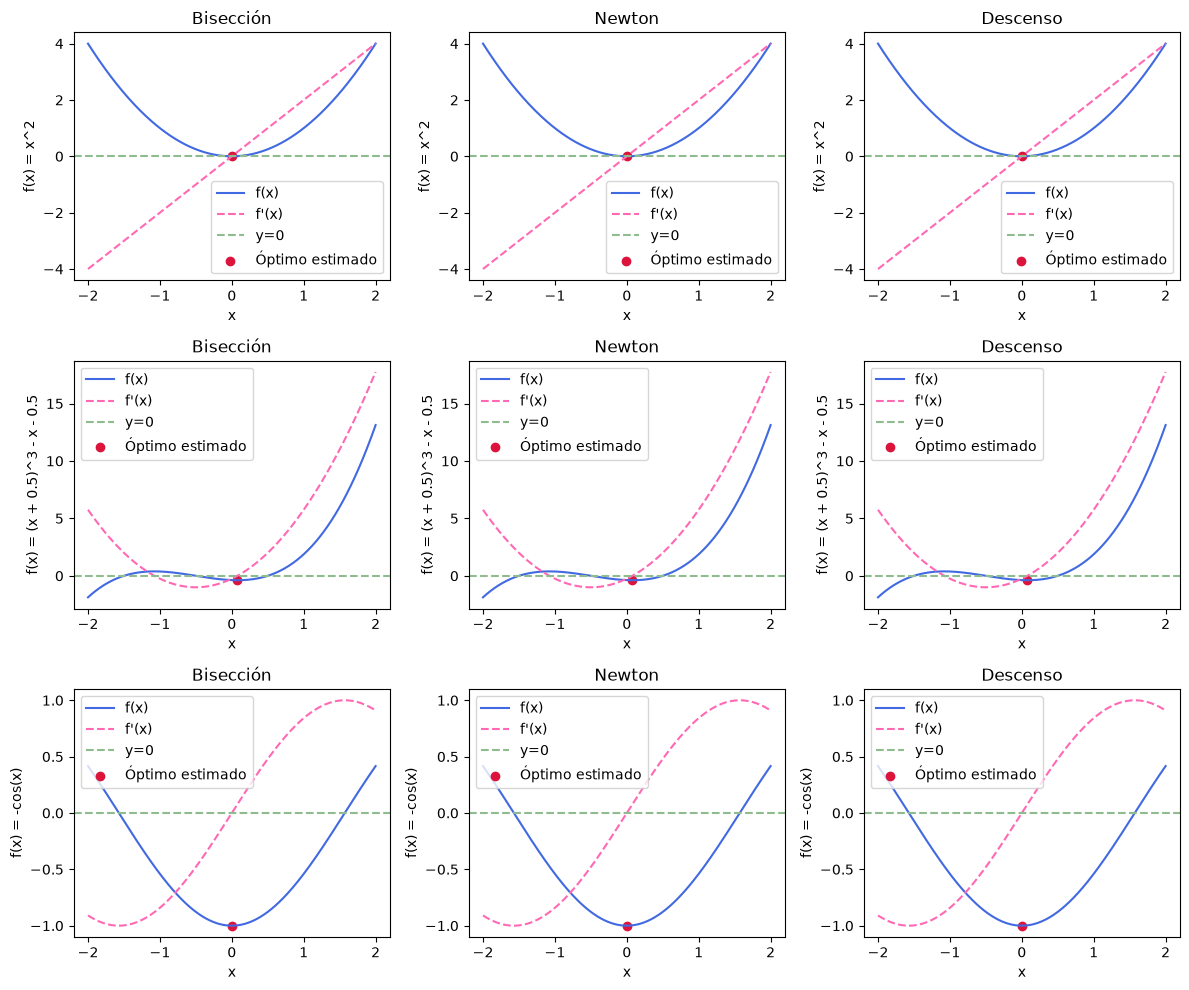

In [131]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step, _ = method(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))), color="royalblue")
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="hotpink")
        ax.axhline(0, linestyle="--", color="darkseagreen")
        ax.scatter(res, f.eval(res), color="crimson")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.show()

# Aplicación a función no trivial

In [147]:
f = x**2 + 2*sin(3*x)

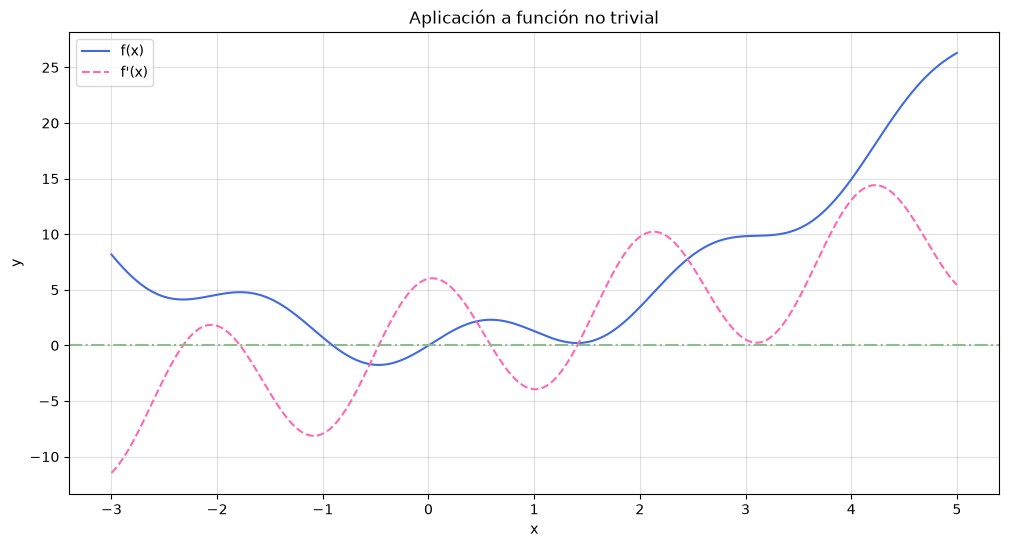

In [148]:
lp = np.linspace(-3, 5, 1000)

df = f.derivative()

f_values = [f.eval(v) for v in lp]
df_values = [df.eval(v) for v in lp]

plt.figure(figsize=(12,6))

plt.plot(
    lp,
    f_values,
    label="f(x)",
    color="royalblue"
)

plt.plot(
    lp,
    df_values,
    "--",
    label="f'(x)",
    color="hotpink"
)

plt.axhline(
    0,
    linestyle="-.",
    color="darkseagreen"
)

plt.title("Aplicación a función no trivial")
plt.xlabel("x")
plt.ylabel("y")

plt.legend()

plt.grid(True, alpha=0.4)
plt.show()

In [149]:
predicciones = {
    ("Biseccion", "[-2,1]"): "≈ -1.7",
    ("Biseccion", "[-1,0]"): "≈ -0.45",
    ("Biseccion", "[1,2]"): "≈ 1.4",
    ("Newton", "-2"): "≈ -1.7",
    ("Newton", "-1"): "≈ -1.7 /≈ -0.45",
    ("Newton", "4"): "Mínimo local derecha",
    ("Gradiente", "-3"): "≈ -2.4",
    ("Gradiente", "0.585"): "≈ 0.6",
    ("Gradiente", "4"): "≈ 1.4",
}

experimentos = []

# Bisección
for a, b in [(-2, 1), (-1, 0), (1, 2)]:
    key = ("Biseccion", f"[{a},{b}]")
    try:
        r, it, _ = biseccion(f, a, b)
        experimentos.append({
            "Método": "Bisección",
            "Inicial": f"[{a},{b}]",
            "Predicción": predicciones[key],
            "Resultado": round(r, 6),
            "Iteraciones": it,
        })
    except Exception as e:
        experimentos.append({
            "Método": "Bisección",
            "Inicial": f"[{a},{b}]",
            "Predicción": predicciones[key],
            "Resultado": str(e),
            "Iteraciones": None,
        })

# Newton 
for x0 in [-2, -1, 4]:
    key = ("Newton", str(x0))
    r, it, _ = newton(f, x0)
    experimentos.append({
        "Método": "Newton",
        "Inicial": x0,
        "Predicción": predicciones[key],
        "Resultado": round(r, 6),
        "Iteraciones": it,
    })

# Descenso por gradiente 
for x0 in [-3, 0.585, 4]:
    key = ("Gradiente", str(x0))
    r, it, _ = descenso_gradiente(f, x0=x0, lr=0.01)
    experimentos.append({
        "Método": "Gradiente",
        "Inicial": x0,
        "Predicción": predicciones[key],
        "Resultado": round(r, 6),
        "Iteraciones": it,
    })

df_exp = pd.DataFrame(experimentos)
df_exp

,Método,Inicial,Predicción,Resultado,Iteraciones
0,Bisección,"[-2,1]",≈ -1.7,-1.782932,23
1,Bisección,"[-1,0]",≈ -0.45,-0.471043,24
2,Bisección,"[1,2]",≈ 1.4,1.407957,21
3,Newton,-2,≈ -1.7,-1.782932,5
4,Newton,-1,≈ -1.7 /≈ -0.45,0.589531,4
5,Newton,4,Mínimo local derecha,7.820892,1000
6,Gradiente,-3,≈ -2.4,-2.322813,77
7,Gradiente,0.585,≈ 0.6,-0.471039,89
8,Gradiente,4,≈ 1.4,1.407961,180


In [150]:
learning_rates = [1e-3, 1e-2, 5e-2, 1e-1, 2e-1]
x0_lr = -3

lr_resultados = []
tabla_lr = []

for lr in learning_rates:
    try:
        r, it, hist = descenso_gradiente(
            f,
            x0=x0_lr,
            lr=lr,
            max_iter=5000
        )

        lr_resultados.append(
            (lr, hist, r)
        )

        tabla_lr.append(
            {
                "Learning rate": lr,
                "Resultado": round(r, 6),
                "Iteraciones": it
            }
        )

    except Exception as e:
        tabla_lr.append(
            {
                "Learning rate": lr,
                "Resultado": "ERROR",
                "Iteraciones": None
            }
        )

df_lr = pd.DataFrame(tabla_lr)
df_lr

,Learning rate,Resultado,Iteraciones
0,0.001,-2.322881,636
1,0.010,-2.322813,77
2,0.050,-2.322808,12
3,0.100,-2.322807,16
4,0.200,-0.446012,5000


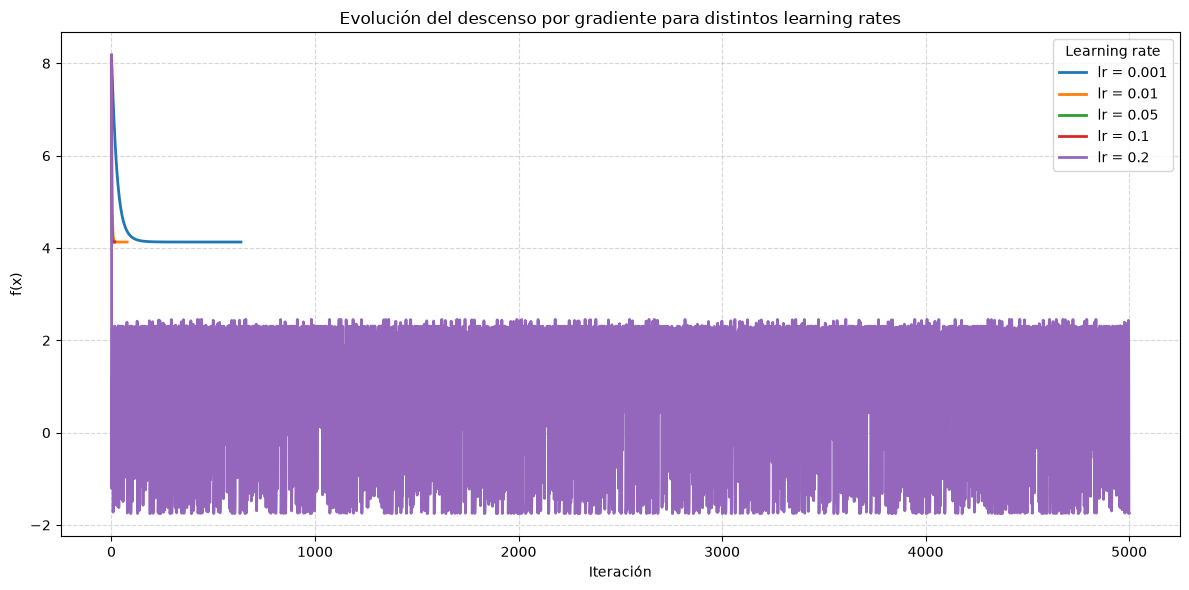

In [151]:
plt.figure(figsize=(12, 6))

for lr, hist, r in lr_resultados:

    plt.plot(
        range(len(hist)),
        [f.eval(v) for v in hist],
        linewidth=2,
        label=f"lr = {lr}"
    )

plt.title(
    "Evolución del descenso por gradiente para distintos learning rates"
)

plt.xlabel("Iteración")
plt.ylabel("f(x)")

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.legend(
    title="Learning rate"
)

plt.tight_layout()
plt.show()

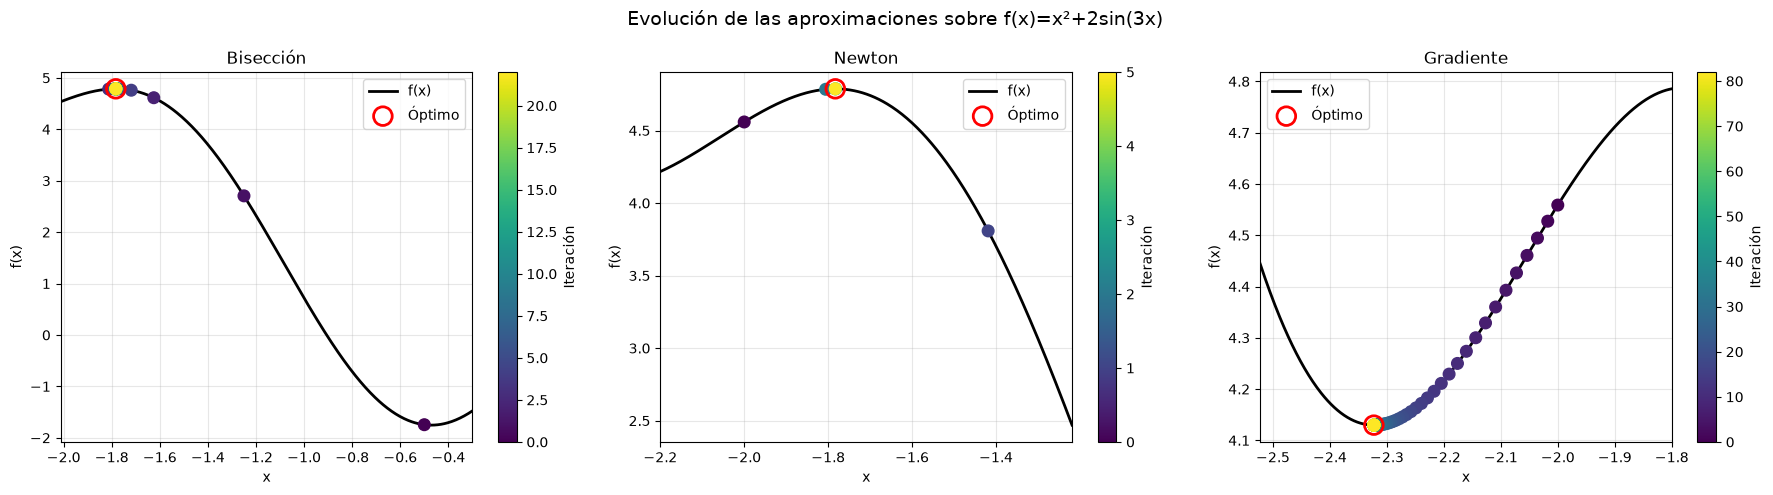

In [152]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metodos = [
    (
        "Bisección",
        biseccion,
        {"a": -2, "b": 1}
    ),
    (
        "Newton",
        newton,
        {"x0": -2}
    ),
    (
        "Gradiente",
        descenso_gradiente,
        {
            "x0": -2,
            "lr": 0.01
        }
    )
]

for ax, (nombre, metodo, params) in zip(axes, metodos):

    resultado, iteraciones, history = metodo(
        f,
        **params
    )

    history = np.array(history)

    # rango para zoom
    xmin = history.min() - 0.2
    xmax = history.max() + 0.2

    lp_zoom = np.linspace(
        xmin,
        xmax,
        500
    )

    # curva de la función
    ax.plot(
        lp_zoom,
        [f.eval(v) for v in lp_zoom],
        color="black",
        linewidth=2,
        label="f(x)"
    )

    # puntos coloreados según iteración
    scatter = ax.scatter(
        history,
        [f.eval(v) for v in history],
        c=range(len(history)),
        cmap="viridis",
        s=70,
        zorder=3
    )

    # óptimo encontrado
    ax.scatter(
        resultado,
        f.eval(resultado),
        s=180,
        facecolors="none",
        edgecolors="red",
        linewidths=2,
        zorder=5,
        label="Óptimo"
    )

    ax.set_title(nombre)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(True, alpha=0.3)

    # zoom horizontal
    ax.set_xlim(xmin, xmax)

    ax.legend()

    # barra de colores
    cbar = plt.colorbar(
        scatter,
        ax=ax
    )

    cbar.set_label("Iteración")

plt.suptitle(
    "Evolución de las aproximaciones sobre f(x)=x²+2sin(3x)",
    fontsize=14
)

plt.tight_layout()
plt.show()

# Ajuste de datos

In [153]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

In [154]:
def loss_lineal(df):

    N = len(df)

    loss = 0

    for _, row in df.iterrows():

        xi = row["x"]
        yi = row["y"]

        pred = w * xi

        loss += (pred - yi)**2

    return loss / N

def loss_exp(df):

    N = len(df)

    loss = 0

    for _, row in df.iterrows():

        xi = row["x"]
        yi = row["y"]

        pred = exp(w * xi)

        loss += (pred - yi)**2

    return loss / N

def loss_sin(df):

    N = len(df)

    loss = 0

    for _, row in df.iterrows():

        xi = row["x"]
        yi = row["y"]

        pred = sin(w * xi)

        loss += (pred - yi)**2

    return loss / N

### Optimización 

In [158]:
loss_lin = loss_lineal(df_linear)
loss_exp_model = loss_exp(df_exp)
loss_sin_model = loss_sin(df_sin)

# Lineal
w_lin, it_lin, hist_lin = descenso_gradiente(
    loss_lin,
    x0=0.0,
    lr=0.001,
    max_iter=10000
)

# Exponencial
w_exp, it_exp, hist_exp = descenso_gradiente(
    loss_exp_model,
    x0=0.1,
    lr=0.001,
    max_iter=10000
)

# Senoidal
w_sin, it_sin, hist_sin = descenso_gradiente(
    loss_sin_model,
    x0=1.5,
    lr=0.001,
    max_iter=10000
)

Tabla de resumen

In [159]:
resultados = pd.DataFrame([
    {
        "Modelo": "Lineal",
        "w óptimo": w_lin,
        "Iteraciones": it_lin
    },
    {
        "Modelo": "Exponencial",
        "w óptimo": w_exp,
        "Iteraciones": it_exp
    },
    {
        "Modelo": "Senoidal",
        "w óptimo": w_sin,
        "Iteraciones": it_sin
    }
])

resultados

,Modelo,w óptimo,Iteraciones
0,Lineal,1.847980,169
1,Exponencial,0.212576,10
2,Senoidal,1.495014,173


### Pérdidas

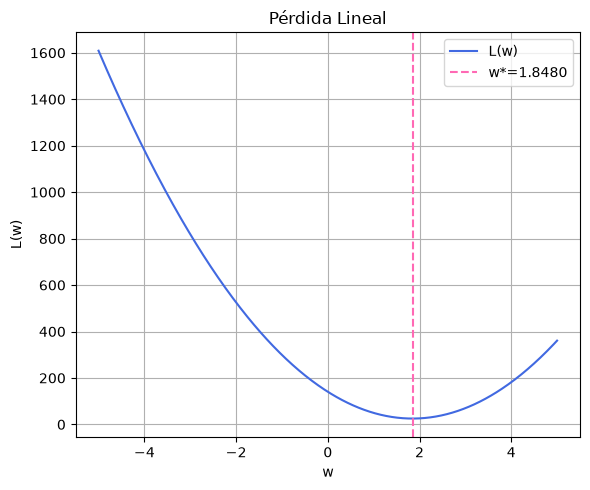

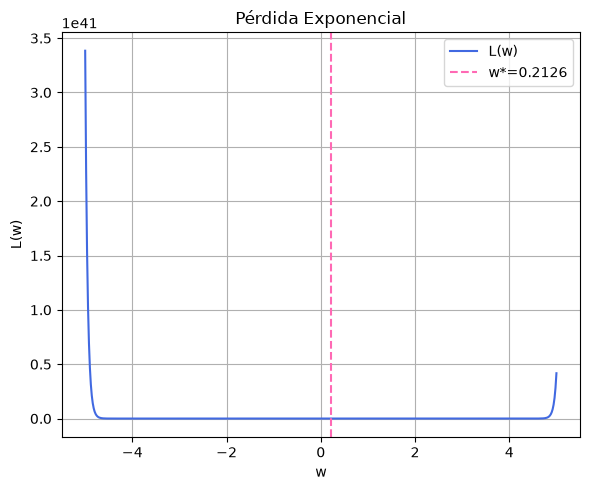

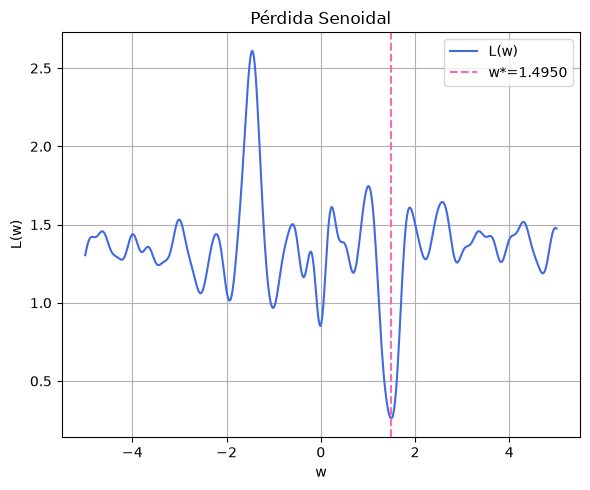

In [160]:
# Lineal
ws = np.linspace(-5, 5, 500)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(ws, [loss_lin.eval(v) for v in ws], label="L(w)", color="royalblue")
ax.axvline(w_lin, linestyle="--", color="hotpink", label=f"w*={w_lin:.4f}")
ax.set_title("Pérdida Lineal")
ax.set_xlabel("w")
ax.set_ylabel("L(w)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Exponencial
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(ws, [loss_exp_model.eval(v) for v in ws], label="L(w)", color="royalblue")
ax.axvline(w_exp, linestyle="--", color="hotpink", label=f"w*={w_exp:.4f}")
ax.set_title("Pérdida Exponencial")
ax.set_xlabel("w")
ax.set_ylabel("L(w)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Senoidal
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(ws, [loss_sin_model.eval(v) for v in ws], label="L(w)", color="royalblue")
ax.axvline(w_sin, linestyle="--", color="hotpink", label=f"w*={w_sin:.4f}")
ax.set_title("Pérdida Senoidal")
ax.set_xlabel("w")
ax.set_ylabel("L(w)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### Ajustes

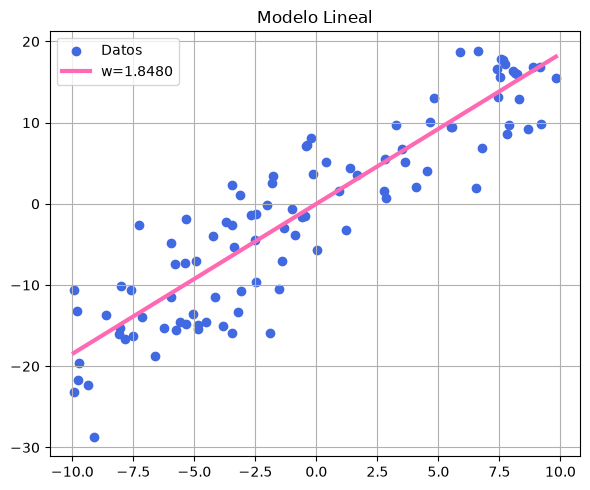

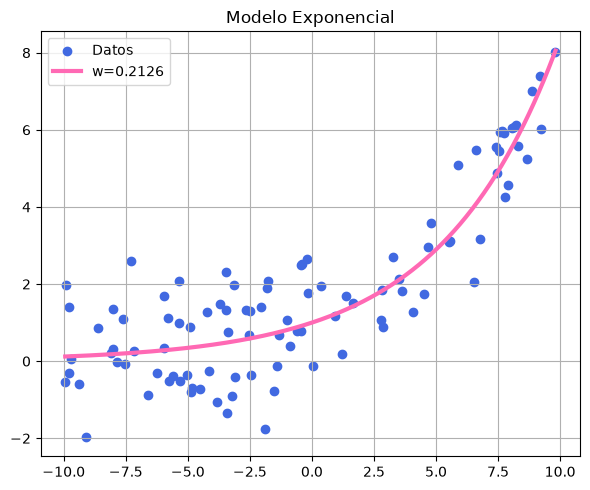

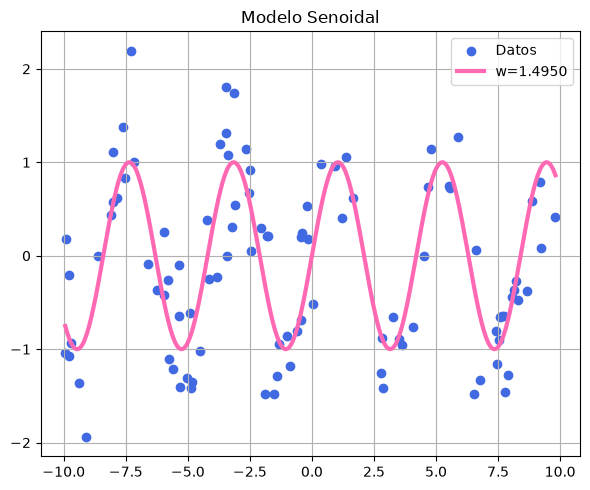

In [161]:
# Lineal
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_linear["x"], df_linear["y"], label="Datos", color="royalblue")
xs = np.linspace(df_linear["x"].min(), df_linear["x"].max(), 500)
ax.plot(xs, w_lin * xs, linewidth=3, label=f"w={w_lin:.4f}", color="hotpink")
ax.set_title("Modelo Lineal")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# Exponencial
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_exp["x"], df_exp["y"], label="Datos", color="royalblue")
xs = np.linspace(df_exp["x"].min(), df_exp["x"].max(), 500)
ax.plot(xs, np.exp(w_exp * xs), linewidth=3, label=f"w={w_exp:.4f}", color="hotpink")
ax.set_title("Modelo Exponencial")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# Senoidal
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_sin["x"], df_sin["y"], label="Datos", color="royalblue")
xs = np.linspace(df_sin["x"].min(), df_sin["x"].max(), 500)
ax.plot(xs, np.sin(w_sin * xs), linewidth=3, label=f"w={w_sin:.4f}", color="hotpink")
ax.set_title("Modelo Senoidal")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# BONUS:

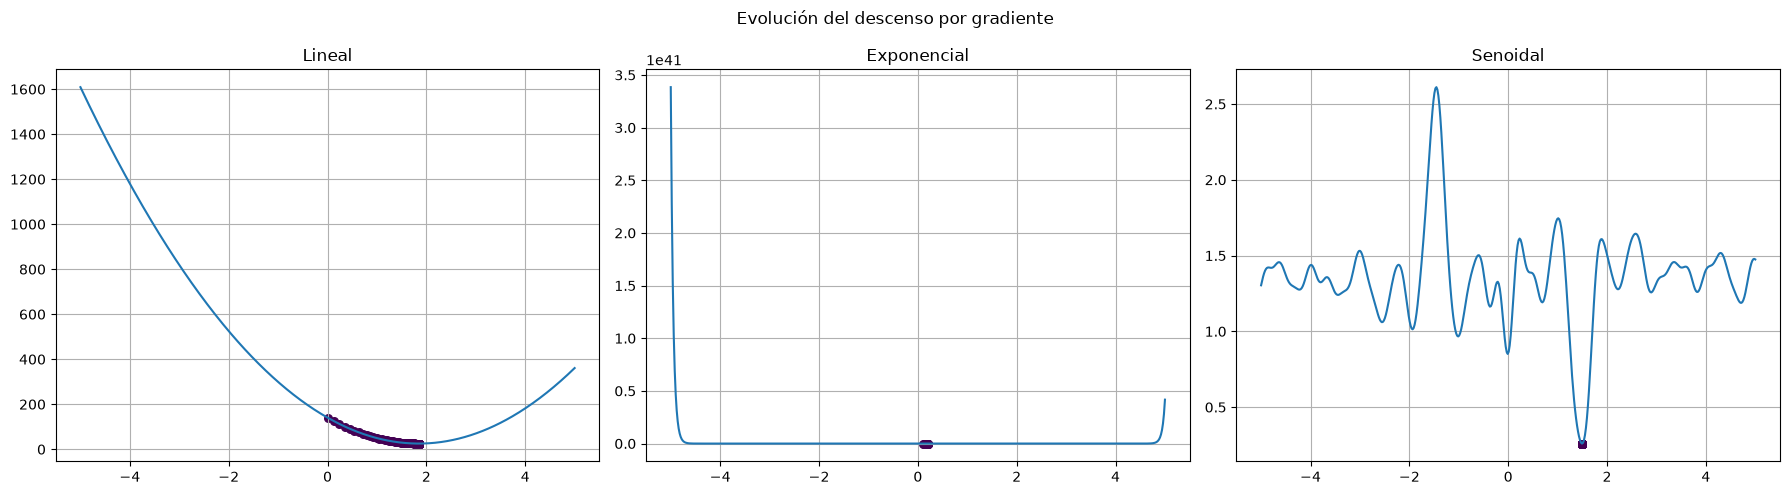

In [162]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

# Lineal
for i, wk in enumerate(hist_lin):

    axes[0].scatter(
        wk,
        loss_lin.eval(wk),
        c=[i],
        cmap="viridis",
        s=30
    )

axes[0].plot(
    ws,
    [loss_lin.eval(v) for v in ws]
)

axes[0].set_title("Lineal")
axes[0].grid(True)

# Exponencial
for i, wk in enumerate(hist_exp):

    axes[1].scatter(
        wk,
        loss_exp_model.eval(wk),
        c=[i],
        cmap="viridis",
        s=30
    )

axes[1].plot(
    ws,
    [loss_exp_model.eval(v) for v in ws]
)

axes[1].set_title("Exponencial")
axes[1].grid(True)

# Senoidal
for i, wk in enumerate(hist_sin):

    axes[2].scatter(
        wk,
        loss_sin_model.eval(wk),
        c=[i],
        cmap="viridis",
        s=30
    )

axes[2].plot(
    ws,
    [loss_sin_model.eval(v) for v in ws]
)

axes[2].set_title("Senoidal")
axes[2].grid(True)

plt.suptitle(
    "Evolución del descenso por gradiente"
)

plt.tight_layout()
plt.show()